In [52]:
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv('vanet_traffic_data.csv')
print(df.isna().sum())
display(df.describe())
display(df)


timestamp                        0
road_segment_id                  0
avg_speed_kmph                   0
density_veh_per_km               0
avg_wait_time_s                  0
occupancy_pct                    0
flow_veh_per_hr                  0
queue_length_veh                 0
avg_accel_ms2                    0
heading_deg                      0
signal_state_num                 0
incident_num                     0
temp_c                           0
visibility_km                    0
rain_intensity_mmph              0
channel_busy_ratio_pct           0
msg_rate_hz                      0
avg_comm_delay_ms                0
rssi_dbm                         0
packet_loss_pct                  0
speed_density_ratio              0
congestion_pressure              0
wireless_congestion_intensity    0
throughput_per_queued_vehicle    0
acceleration_directionality      0
weather_factor                   0
label                            0
dtype: int64


,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,signal_state_num,incident_num,...,msg_rate_hz,avg_comm_delay_ms,rssi_dbm,packet_loss_pct,speed_density_ratio,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor
count,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,...,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000
mean,40.113615,42.531785,41.490966,48.635799,1217.380428,20.595787,0.087940,141.391571,2.318778,0.752956,...,16.590649,81.221076,-61.594159,10.756338,2.703669,29.231785,7.649460,479.399182,21.554183,151.111290
std,23.680900,29.323898,41.245668,31.320898,693.234355,20.800210,0.664306,94.558893,1.090006,0.702711,...,5.498945,64.104660,5.500902,10.716784,3.200042,39.484254,9.924541,1316.049020,65.401348,96.690242
min,1.030000,1.100000,-2.630000,1.390000,41.120000,-1.270000,-1.360000,-16.880000,0.754000,-0.209000,...,6.590000,14.060000,-73.170000,0.160000,0.011100,-0.291000,0.012300,0.626000,-167.467600,12.078400
25%,23.740000,12.010000,7.020000,12.020000,777.080000,2.800000,-0.351000,86.830000,1.060000,0.051000,...,10.800000,21.490000,-65.510000,0.580000,0.392100,0.726600,0.061000,30.063400,-6.825700,71.214650
50%,43.710000,31.910000,21.935000,41.640000,1474.340000,11.030000,0.348000,173.770000,2.039000,0.532000,...,15.510000,51.620000,-60.520000,5.520000,1.400700,6.668150,1.671050,135.860450,59.731750,154.236700
75%,68.010000,61.940000,52.570000,71.590000,1959.920000,26.400000,0.721000,187.480000,3.038000,1.032000,...,20.510000,101.920000,-55.810000,15.770000,5.818675,31.782400,9.516500,712.129100,73.527975,266.234175
max,77.970000,101.200000,137.870000,103.490000,2153.180000,72.990000,1.153000,286.750000,4.270000,2.206000,...,28.350000,214.570000,-51.490000,36.140000,66.406900,127.390100,33.106500,21384.541400,130.857400,338.956700


,timestamp,road_segment_id,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,...,avg_comm_delay_ms,rssi_dbm,packet_loss_pct,speed_density_ratio,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor,label
0,2025-09-29T04:54:49,S090,43.38,24.78,20.57,39.85,1463.49,7.36,0.488,181.26,...,51.66,-60.28,5.56,1.7504,5.0977,1.6645,198.7510,88.4849,156.3778,Moderate
1,2025-09-30T06:15:38,S339,4.50,89.61,120.69,95.67,105.16,55.69,-1.047,0.78,...,204.45,-69.48,30.34,0.0502,108.1477,26.7853,1.8885,-0.8207,20.1982,Gridlock
2,2025-09-29T05:46:06,S167,45.68,29.45,17.79,42.26,1536.62,11.43,0.462,184.61,...,49.53,-58.90,4.60,1.5510,5.2396,1.3304,134.4387,85.2133,150.1454,Moderate
3,2025-09-28T21:15:29,S030,44.34,30.17,27.13,34.66,1486.33,9.63,0.550,174.62,...,49.64,-60.43,5.30,1.4700,8.1846,1.6631,154.2838,96.0502,149.7671,Moderate
4,2025-09-28T00:29:20,S261,66.86,5.30,7.86,12.45,1954.74,1.75,0.757,88.26,...,21.00,-55.23,0.30,12.6102,0.4169,0.0236,1117.7505,66.8219,259.8905,Free-flow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195709,2025-09-29T10:31:02,S263,26.30,66.01,53.02,70.74,744.50,26.07,-0.241,274.81,...,100.80,-67.15,14.99,0.3984,34.9938,9.5996,28.5524,-66.2181,83.2174,Heavy
195710,2025-09-30T09:40:09,S110,3.58,91.89,117.03,95.91,97.87,57.41,-0.994,4.01,...,206.83,-68.84,28.08,0.0389,107.5470,25.4410,1.7048,-3.9889,19.1545,Gridlock
195711,2025-09-28T04:55:30,S231,69.36,7.51,4.77,9.04,1926.89,2.14,0.822,90.88,...,19.95,-55.41,0.56,9.2325,0.3582,0.0511,899.0544,74.6984,289.8708,Free-flow
195712,2025-09-28T07:47:10,S031,72.34,13.24,2.16,12.73,2122.19,1.85,0.741,88.20,...,19.79,-55.26,0.33,5.4641,0.2863,0.0358,1144.6198,65.3728,288.3522,Free-flow


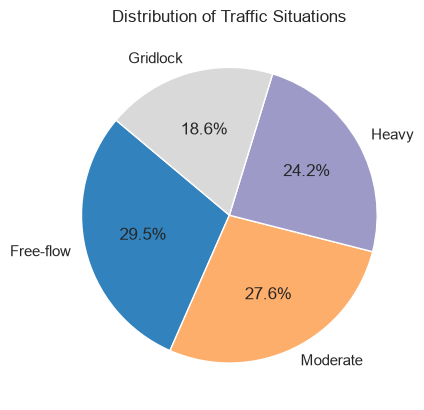

C:\Users\Blackhaw\AppData\Local\Temp\ipykernel_10248\2264624625.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='avg_speed_kmph', data=df, order=traffic_order, palette='muted')


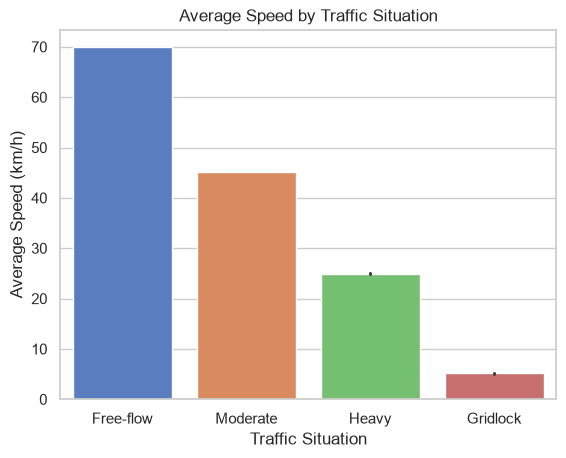

C:\Users\Blackhaw\AppData\Local\Temp\ipykernel_10248\2264624625.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='queue_length_veh', data=df, order=traffic_order, palette='magma')


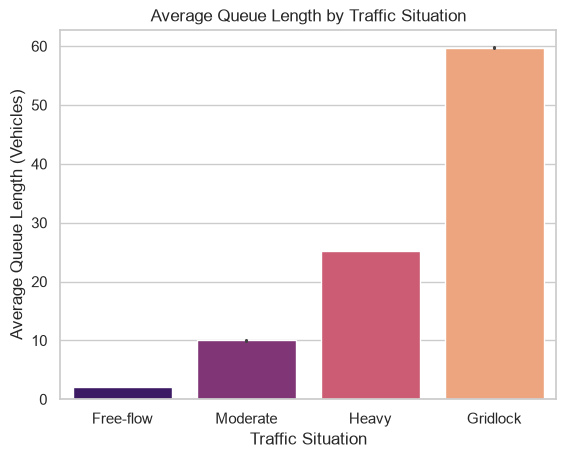

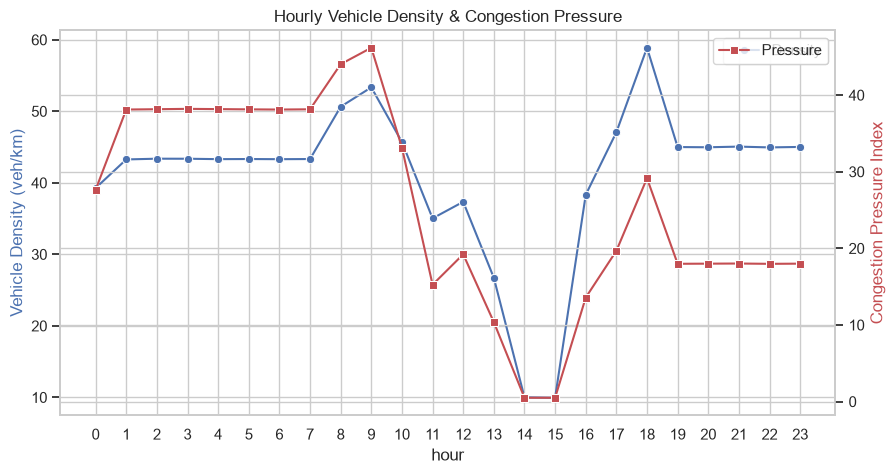

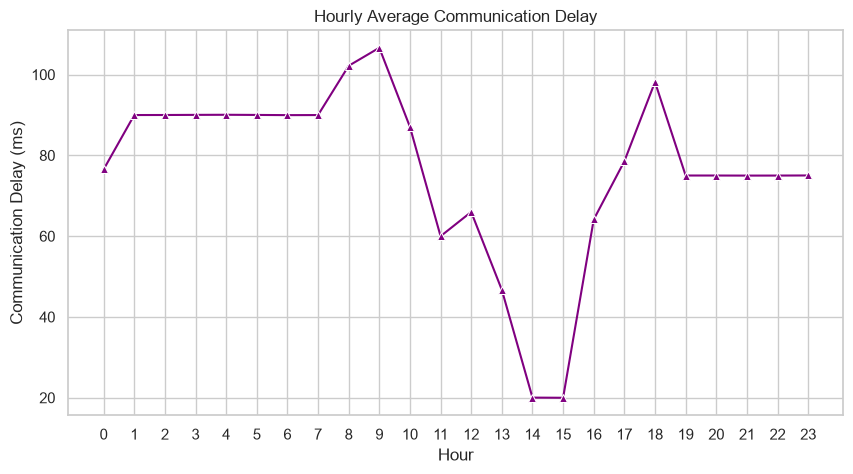

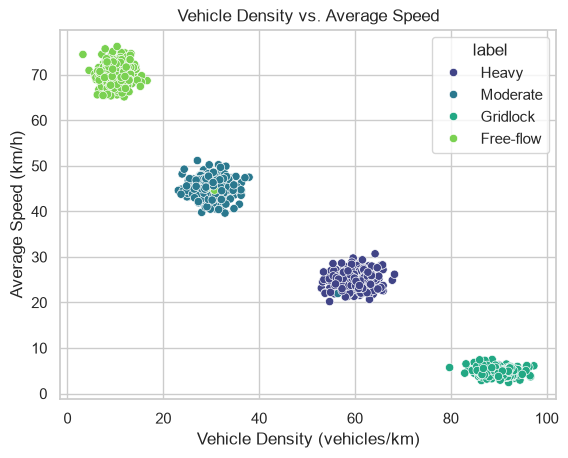

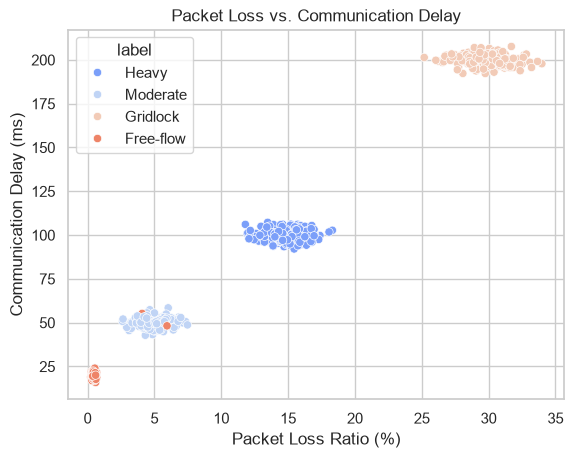

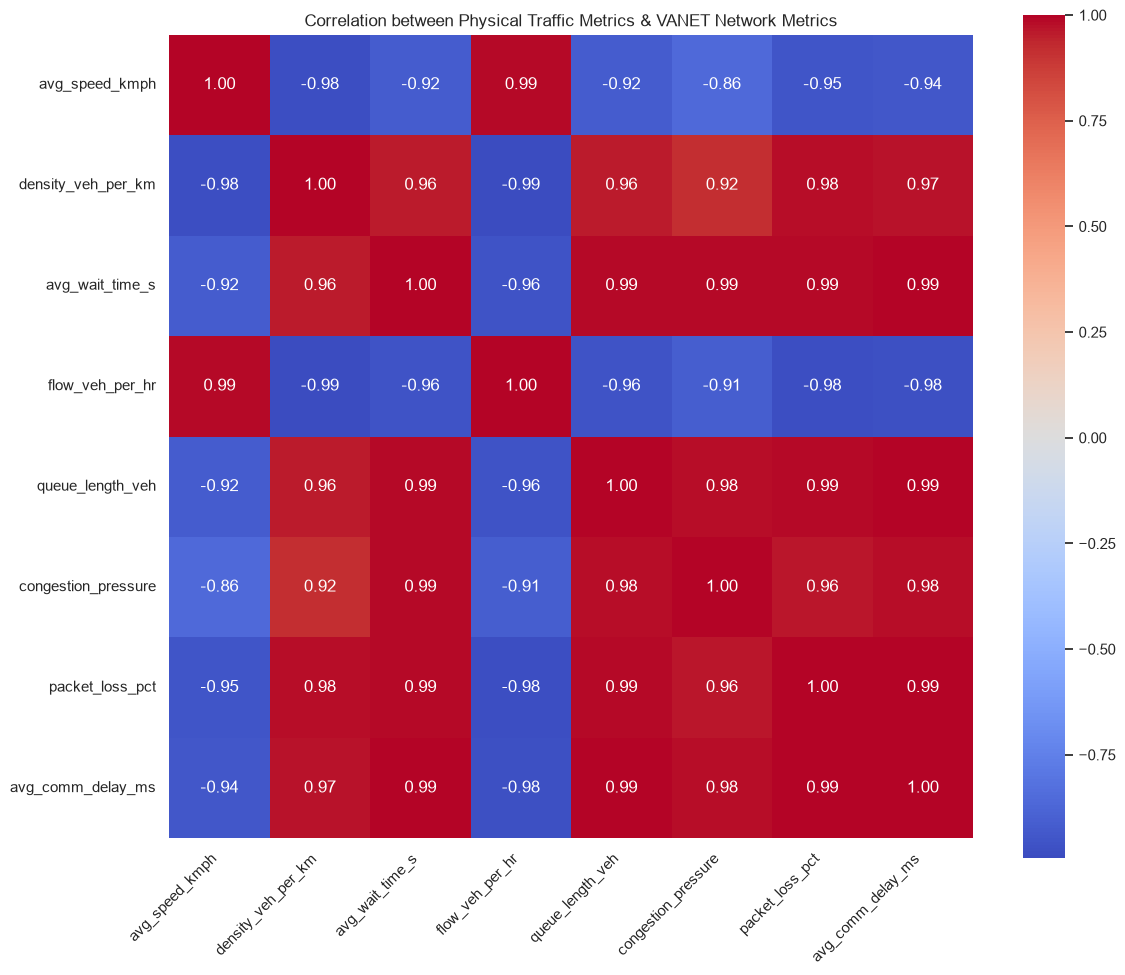

In [53]:
sns.set_theme(style="whitegrid")
traffic_order = ['Free-flow', 'Moderate', 'Heavy', 'Gridlock']
df_sample = df.sample(1000, random_state=42) #sample

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='tab20c')
plt.title('Distribution of Traffic Situations')
plt.show()

sns.barplot(x='label', y='avg_speed_kmph', data=df, order=traffic_order, palette='muted')
plt.title('Average Speed by Traffic Situation')
plt.xlabel('Traffic Situation')
plt.ylabel('Average Speed (km/h)')
plt.show()

sns.barplot(x='label', y='queue_length_veh', data=df, order=traffic_order, palette='magma')
plt.title('Average Queue Length by Traffic Situation')
plt.xlabel('Traffic Situation')
plt.ylabel('Average Queue Length (Vehicles)')
plt.show()


hourly_stats = df.groupby('hour')[['density_veh_per_km', 'congestion_pressure']].mean()
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
sns.lineplot(x='hour', y='density_veh_per_km', data=hourly_stats, color='b', marker='o', ax=ax1, label='Density')
sns.lineplot(x='hour', y='congestion_pressure', data=hourly_stats, color='r', marker='s', ax=ax2, label='Pressure')
ax1.set_ylabel('Vehicle Density (veh/km)', color='b')
ax2.set_ylabel('Congestion Pressure Index', color='r')
plt.xticks(np.arange(0,24))
plt.title('Hourly Vehicle Density & Congestion Pressure')
plt.show()


fig, ax = plt.subplots(figsize=(10, 5))
hourly_comm = pd.DataFrame(df.groupby('hour')['avg_comm_delay_ms'].mean())
sns.lineplot(x='hour', y='avg_comm_delay_ms', data=hourly_comm, color='purple', marker='^',ax=ax)
plt.title('Hourly Average Communication Delay')
plt.xlabel('Hour')
plt.ylabel('Communication Delay (ms)')
plt.xticks(np.arange(0,24))
plt.show()


sns.scatterplot(x='density_veh_per_km', y='avg_speed_kmph', hue='label', data=df_sample, palette='viridis')
plt.title('Vehicle Density vs. Average Speed')
plt.xlabel('Vehicle Density (vehicles/km)')
plt.ylabel('Average Speed (km/h)')
plt.show()


sns.scatterplot(x='packet_loss_pct', y='avg_comm_delay_ms', hue='label', data=df_sample, palette='coolwarm')
plt.title('Packet Loss vs. Communication Delay')
plt.xlabel('Packet Loss Ratio (%)')
plt.ylabel('Communication Delay (ms)')
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))

metrics = ['avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'flow_veh_per_hr', 
                'queue_length_veh', 'congestion_pressure', 'packet_loss_pct', 'avg_comm_delay_ms']
sns.heatmap(df[metrics].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True,ax=ax)
plt.title('Correlation between Physical Traffic Metrics & VANET Network Metrics')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [54]:
exclude_cols = ['timestamp', 'road_segment_id', 'label']
feature_cols = [col for col in df.columns if col not in exclude_cols]
feature_lite_cols = ['flow_veh_per_hr', 'speed_density_ratio', 'avg_comm_delay_ms', 
    'channel_busy_ratio_pct', 'incident_num', 'wireless_congestion_intensity', 
    'density_veh_per_km', 'avg_speed_kmph', 'packet_loss_pct', 'visibility_km']

X = df[feature_cols]
X_lite = df[feature_lite_cols]
y = df['label']

def TrainModel(X,y):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )


    print(X_train.shape)


    model = RandomForestClassifier(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred))

    importances = model.feature_importances_
    sorted_indices = np.argsort(importances)[::-1]

    for i in range(X.shape[1]):
        idx = sorted_indices[i]
        print(f"  {i+1}. {feature_cols[idx]}: {importances[idx] * 100:.2f}% importance")

    return model

rf_model = TrainModel(X,y)
rf_lite_model = TrainModel(X_lite,y)
joblib.dump(rf_model,"TrafficTypeClassifier.model")
joblib.dump(rf_lite_model,"TrafficTypeClassifierLite.model")






(136999, 26)
              precision    recall  f1-score   support

   Free-flow       0.99      1.00      0.99     17344
    Gridlock       0.99      0.99      0.99     10933
       Heavy       0.99      0.99      0.99     14232
    Moderate       0.99      0.99      0.99     16206

    accuracy                           0.99     58715
   macro avg       0.99      0.99      0.99     58715
weighted avg       0.99      0.99      0.99     58715

  1. flow_veh_per_hr: 11.00% importance
  2. speed_density_ratio: 8.22% importance
  3. avg_comm_delay_ms: 7.81% importance
  4. channel_busy_ratio_pct: 7.42% importance
  5. incident_num: 7.29% importance
  6. wireless_congestion_intensity: 7.11% importance
  7. density_veh_per_km: 5.67% importance
  8. avg_speed_kmph: 5.60% importance
  9. packet_loss_pct: 5.38% importance
  10. visibility_km: 4.99% importance
  11. occupancy_pct: 4.93% importance
  12. rain_intensity_mmph: 4.51% importance
  13. throughput_per_queued_vehicle: 3.86% importance


['TrafficTypeClassifierLite.model']

In [55]:
target_col = 'avg_wait_time_s'
predictor_cols = ['flow_veh_per_hr', 'density_veh_per_km', 'queue_length_veh', 'signal_state_num']

X = df[predictor_cols]
y = df[target_col]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


reg_model = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
reg_model.fit(X_train, y_train)


y_pred = reg_model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"mae: {mae} seconds")
print(f"r2: {r2*100}%)")



importances = reg_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]


for rank, idx in enumerate(sorted_idx):
    print(f"  {rank+1}. {predictor_cols[idx]}: {importances[idx] * 100:.2f}% importance")


joblib.dump(reg_model,"WaitTimeRegressor.model")

mae: 2.514189919854333 seconds
r2: 99.37755188236343%)
  1. flow_veh_per_hr: 43.14% importance
  2. density_veh_per_km: 26.51% importance
  3. signal_state_num: 23.64% importance
  4. queue_length_veh: 6.71% importance


['WaitTimeRegressor.model']